In [1]:
import os
import rasterio
import yaml

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [2]:
os.chdir("..")

In [3]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

In [4]:
# project paths
data_dir = Path(config["data_dir"])
data_dir_processed = data_dir / "processed"
out_multiband = data_dir_processed / "output_multiband.tif"

aoi_path = data_dir / "aoi.geojson"

In [6]:
BAND_IDX = {
    "B01": 1,
    "B02": 2,
    "B03": 3,
    "B04": 4,
    "B05": 5,
    "B06": 6,
    "B07": 7,
    "B08": 8,
    "B09": 9,
    "B11": 10,
    "B12": 11,
    "B8A": 12,
}

In [7]:
with rasterio.open(out_multiband) as src:
    b02 = src.read(BAND_IDX["B02"])
    b03 = src.read(BAND_IDX["B03"])
    b04 = src.read(BAND_IDX["B04"])
    b05 = src.read(BAND_IDX["B05"])
    b08 = src.read(BAND_IDX["B08"])
    b8a = src.read(BAND_IDX["B8A"])

## True color

In [18]:
rgb = np.stack([b04, b03, b02])

In [20]:
rgb = np.moveaxis(rgb, 0, -1)

In [63]:
rgb_display = np.clip(rgb / 0.4, 0, 1)

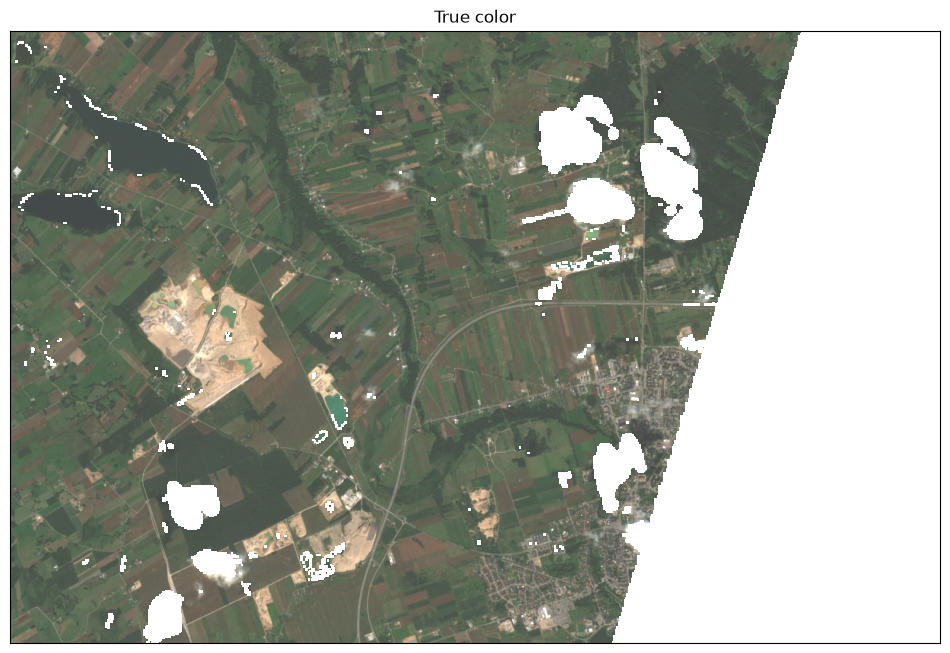

In [72]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.imshow(rgb_display);
ax.set_title("True color");

ax.get_xaxis().set_visible(False)
ax.get_yaxis().set_visible(False)

## NDVI

In [8]:
# calculate NDVI
numerator = b08 - b04
denominator = b08 + b04

ndvi = np.divide(numerator, denominator, out=np.full(b08.shape, np.nan, dtype=np.float32), where=denominator != 0)

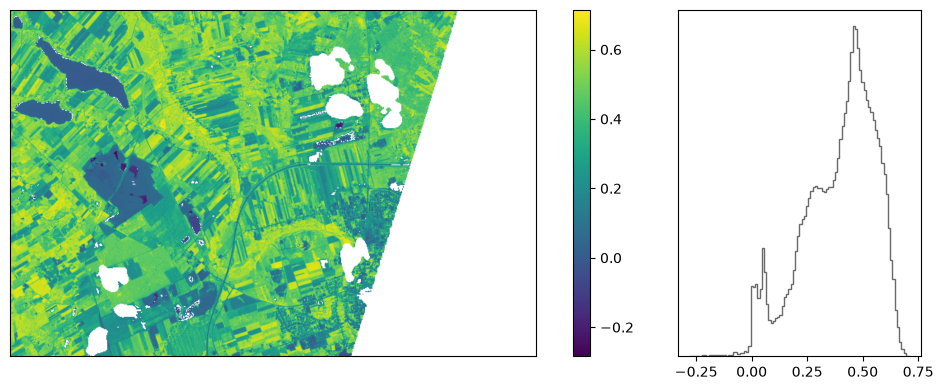

In [58]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[3, 1])
im = ax[0].imshow(ndvi, cmap="viridis")
ax[1].hist(ndvi[np.isfinite(ndvi)], bins=100, histtype="step", color="dimgray");
fig.colorbar(im, ax=ax[0])

ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].get_yaxis().set_visible(False)
plt.tight_layout()

## EVI

In [10]:
# calculate EVI
numerator = b08 - b04
denominator = b8a + 6 * b04 - 7.5 * b02 + 1

evi = 2.5 * np.divide(numerator, denominator, out=np.full(b8a.shape, np.nan, dtype=np.float32), where=denominator != 0)

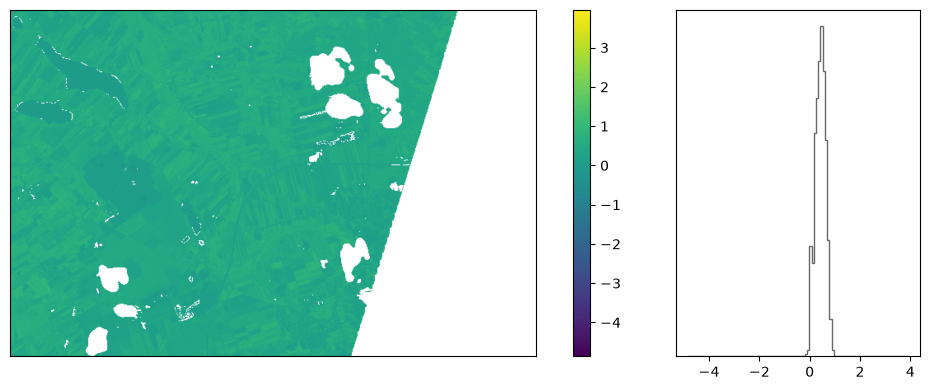

In [59]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[3, 1])
im = ax[0].imshow(evi, cmap="viridis")
ax[1].hist(evi[np.isfinite(evi)], bins=100, histtype="step", color="dimgray");
fig.colorbar(im, ax=ax[0])

ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].get_yaxis().set_visible(False)
plt.tight_layout()

## SAVI

In [12]:
# calculate SAVI
# L is a soil brightness correction factor (typically 0.5)
L = 0.5
numerator = b08 - b04
denominator = b08 + b04 + L

savi = np.divide(numerator, denominator, out=np.full(b08.shape, np.nan, dtype=np.float64), where=denominator > 0) * (L + 1)

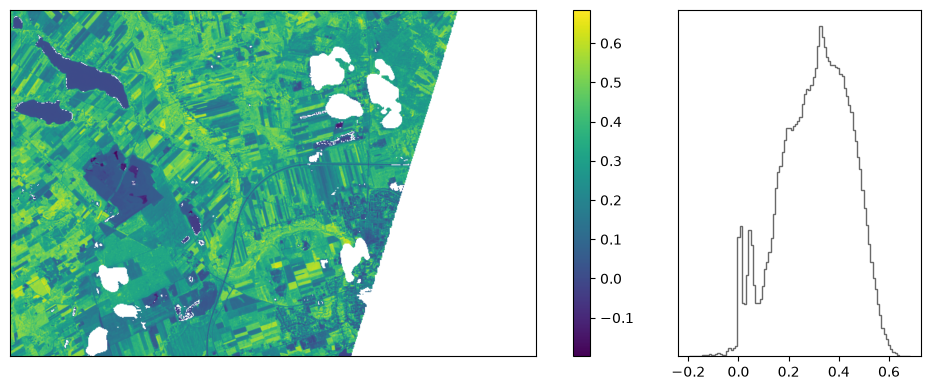

In [60]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[3, 1])
im = ax[0].imshow(savi, cmap="viridis")
ax[1].hist(savi[np.isfinite(savi)], bins=100, histtype="step", color="dimgray");
fig.colorbar(im, ax=ax[0])

ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].get_yaxis().set_visible(False)
plt.tight_layout()

## NDRE

In [14]:
# calculate NDRE
numerator = b8a - b05
denominator = b8a + b05

ndre = np.divide(numerator, denominator, out=np.full(b8a.shape, np.nan, dtype=np.float32), where=denominator != 0)

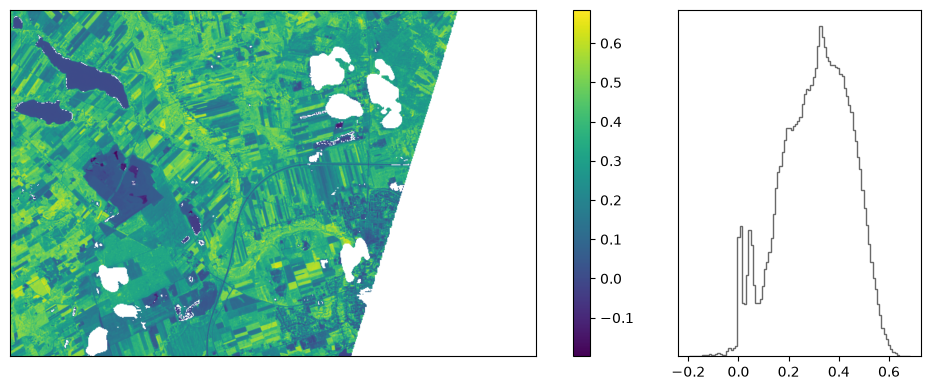

In [61]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[3, 1])
im = ax[0].imshow(savi, cmap="viridis")
ax[1].hist(savi[np.isfinite(savi)], bins=100, histtype="step", color="dimgray");
fig.colorbar(im, ax=ax[0])

ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].get_yaxis().set_visible(False)
plt.tight_layout()

## GNDVI

In [16]:
# calculate GNDVI
numerator = b08 - b03
denominator = b08 + b03

gndvi = np.divide(numerator, denominator, out=np.full(b08.shape, np.nan, dtype=np.float64), where=denominator != 0)

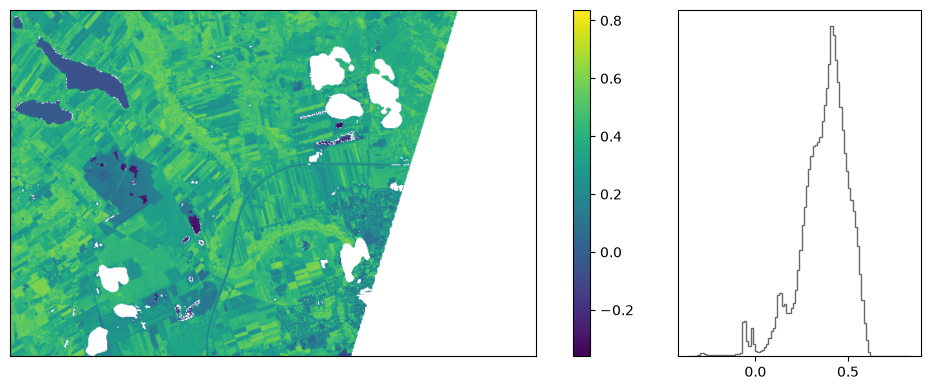

In [62]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), width_ratios=[3, 1])
im = ax[0].imshow(gndvi, cmap="viridis")
ax[1].hist(gndvi[np.isfinite(gndvi)], bins=100, histtype="step", color="dimgray");
fig.colorbar(im, ax=ax[0])

ax[0].get_xaxis().set_visible(False)
ax[0].get_yaxis().set_visible(False)

ax[1].get_yaxis().set_visible(False)
plt.tight_layout()